<a href="https://colab.research.google.com/github/navyasreeg2025-bot/eda-lab-experiment/blob/main/18_08_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()


Saving WineQT.csv to WineQT (1).csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pandas.plotting import scatter_matrix

In [20]:
df = pd.read_csv("WineQT.csv")
print(df.head())
print()
print(df.shape)
print()
print(df.columns)
print()
print(df.dtypes)
print()
print(df.isnull().sum())

   fixed acidity  volatile acidity  citric acid  ...  alcohol  quality  Id
0            7.4              0.70         0.00  ...      9.4        5   0
1            7.8              0.88         0.00  ...      9.8        5   1
2            7.8              0.76         0.04  ...      9.8        5   2
3           11.2              0.28         0.56  ...      9.8        6   3
4            7.4              0.70         0.00  ...      9.4        5   4

[5 rows x 13 columns]

(1143, 13)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      f

In [7]:
print(df.describe())

       fixed acidity  volatile acidity  ...      quality           Id
count    1143.000000       1143.000000  ...  1143.000000  1143.000000
mean        8.311111          0.531339  ...     5.657043   804.969379
std         1.747595          0.179633  ...     0.805824   463.997116
min         4.600000          0.120000  ...     3.000000     0.000000
25%         7.100000          0.392500  ...     5.000000   411.000000
50%         7.900000          0.520000  ...     6.000000   794.000000
75%         9.100000          0.640000  ...     6.000000  1209.500000
max        15.900000          1.580000  ...     8.000000  1597.000000

[8 rows x 13 columns]


In [8]:
print("Mean:", df["quality"].mean())
print("Median:", df["quality"].median())
print("Mode:", df["quality"].mode()[0])
print("Std Dev:", df["quality"].std())
print("Variance:", df["quality"].var())

Mean: 5.657042869641295
Median: 6.0
Mode: 5
Std Dev: 0.8058242481000936
Variance: 0.6493527188260811


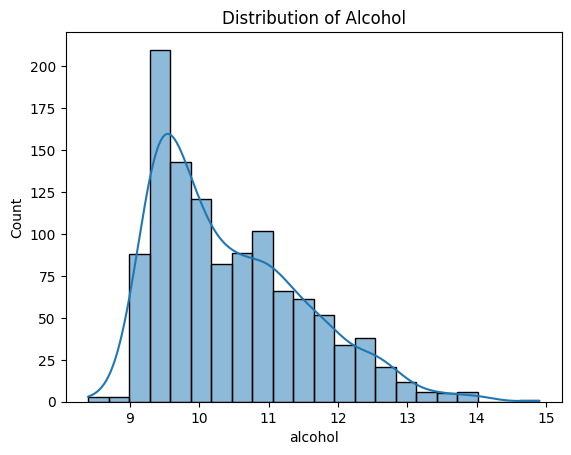

In [9]:
sns.histplot(df["alcohol"], kde=True)
plt.title("Distribution of Alcohol")
plt.show()

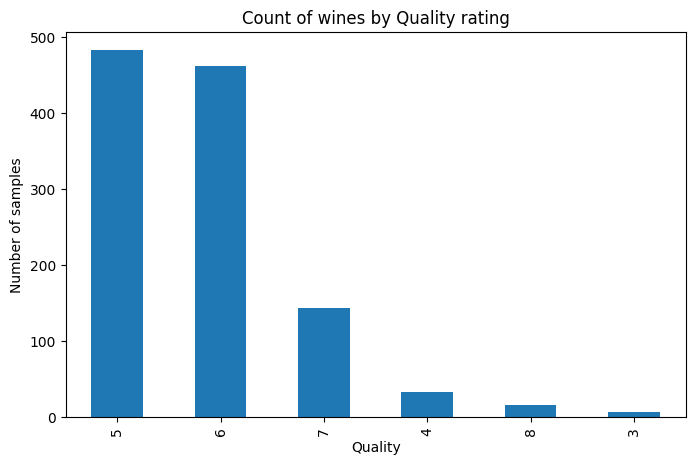

In [10]:
df["quality"].value_counts().plot(kind='bar', figsize=(8,5))
plt.title("Count of wines by Quality rating")
plt.xlabel("Quality")
plt.ylabel("Number of samples")
plt.show()

In [22]:
correlation = df.corr(method='pearson', numeric_only=True)
print(correlation['quality'].sort_values(ascending=False))

quality                 1.000000
alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
Id                      0.069708
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64


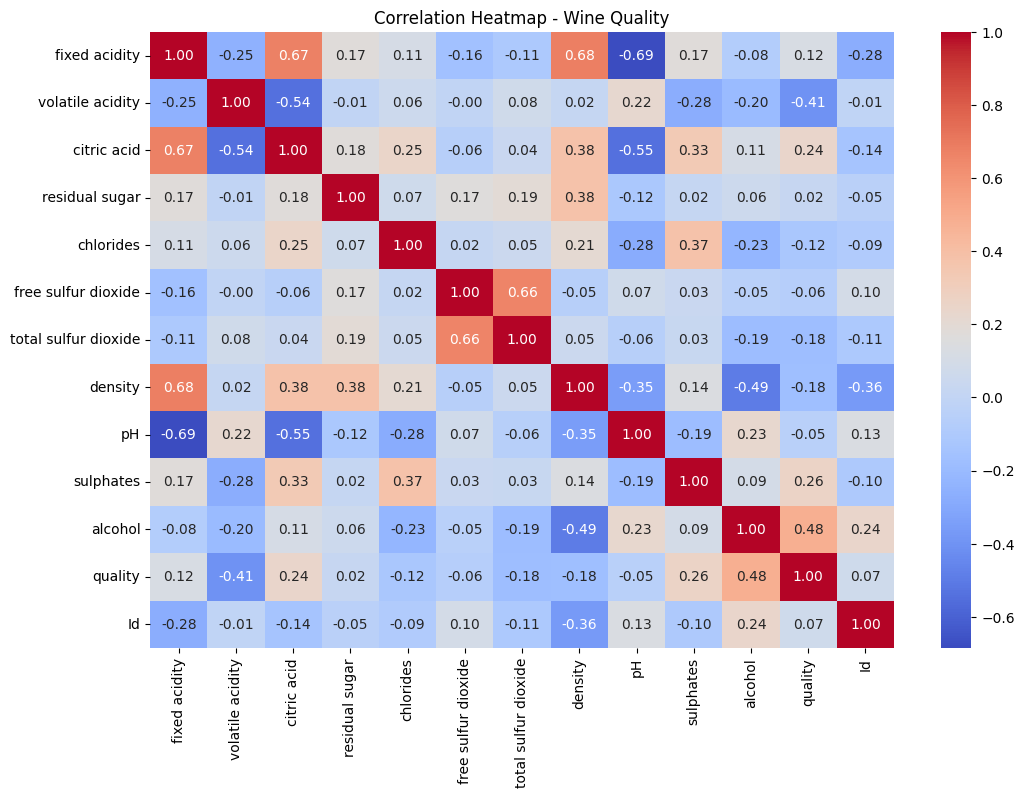

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Wine Quality")
plt.show()

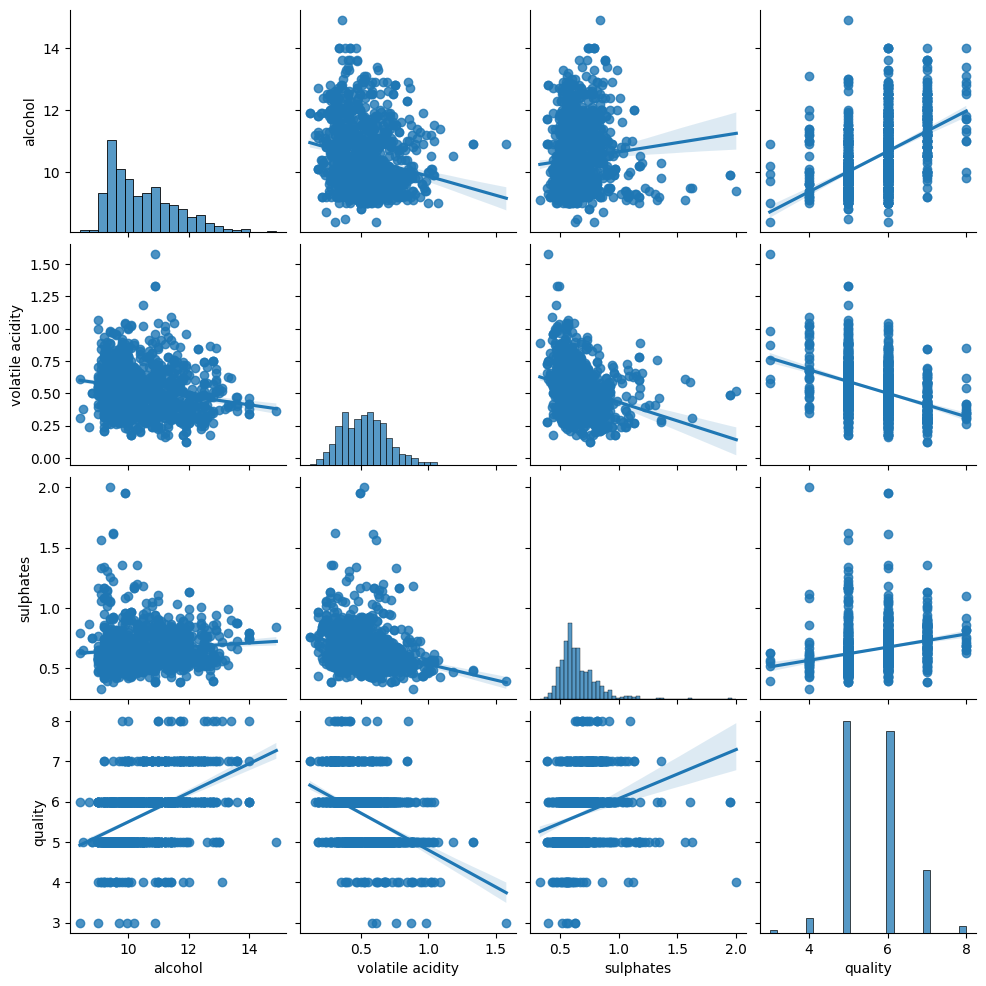

In [14]:
sns.pairplot(df, vars=['alcohol', 'volatile acidity', 'sulphates', 'quality'],kind="reg")
plt.show()

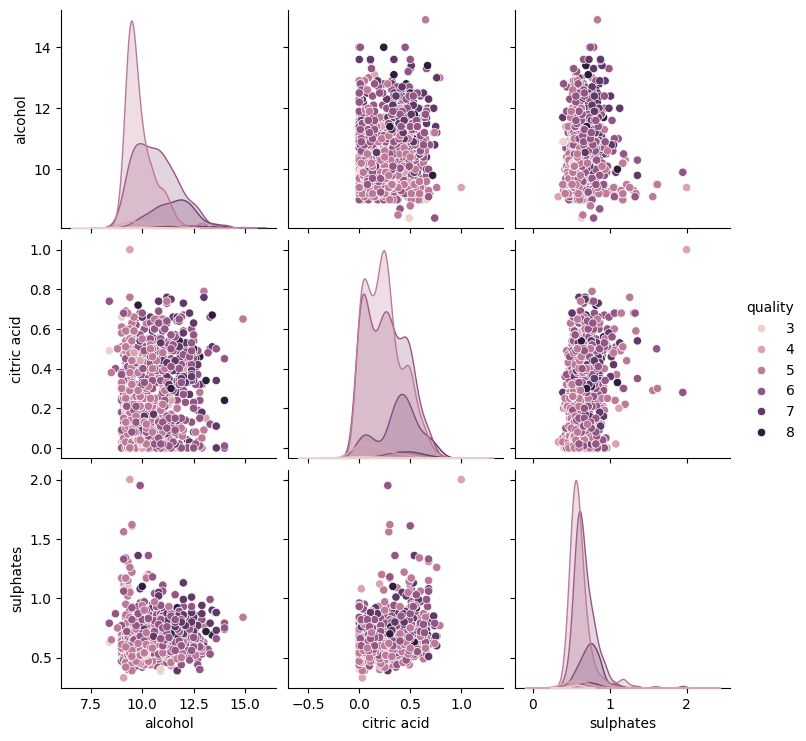

In [15]:
sns.pairplot(df, vars=['alcohol', 'citric acid', 'sulphates'], hue="quality")
plt.show()

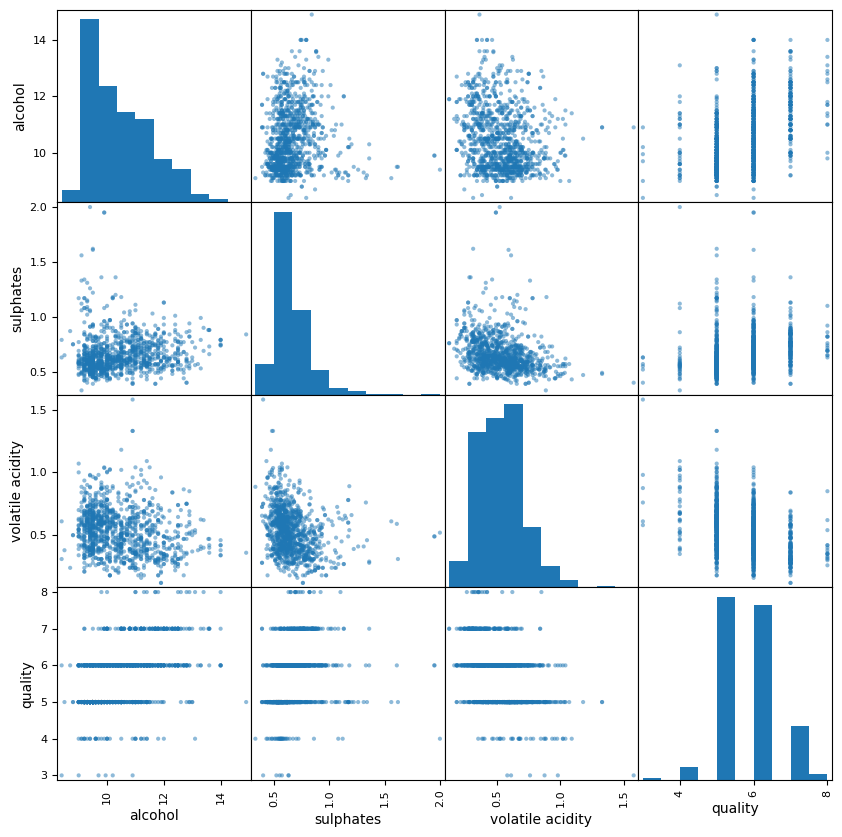

In [16]:
scatter_matrix(df[['alcohol','sulphates','volatile acidity','quality']], figsize=(10,10))
plt.show()

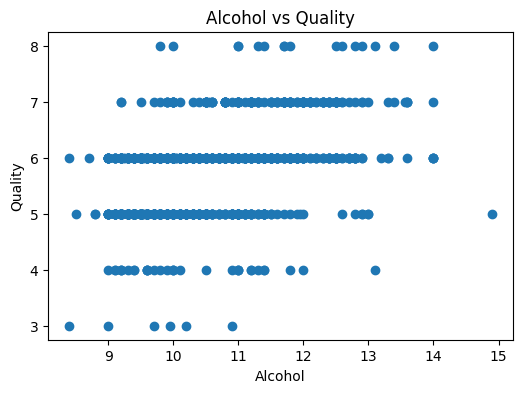

In [17]:
plt.figure(figsize=(6,4))
plt.scatter(df["alcohol"], df["quality"])
plt.title("Alcohol vs Quality")
plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.show()

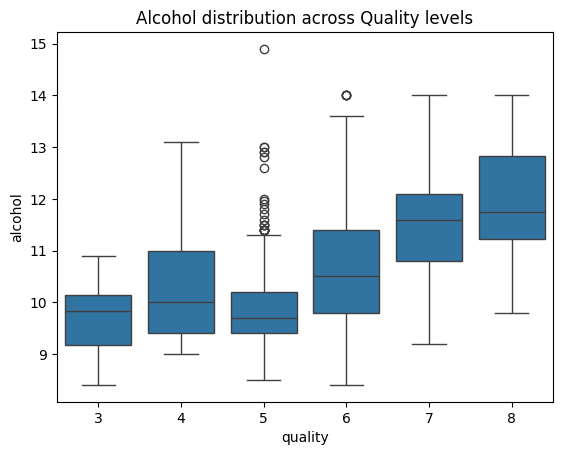

In [18]:
sns.boxplot(x="quality", y="alcohol", data=df)
plt.title("Alcohol distribution across Quality levels")
plt.show()

In [19]:
corr, pval = stats.pearsonr(df["alcohol"], df["quality"])
print("Correlation:", corr)
print("p-value:", pval)


Correlation: 0.4848662118085117
p-value: 1.9246528151001656e-68
